# Notebook 08: Visualisasi Atensi Biomekanis — Tiga Panel Per Gerakan

Notebook ini menghasilkan satu figure dengan **tiga panel 3D** yang menampilkan:
- **Panel Kiri   → Squat**       — Sudut kamera: Frontal (elev=10°, azim=−60°)
- **Panel Tengah → Deadlift**    — Sudut kamera: Sagital/Samping (elev=10°, azim=0°)
- **Panel Kanan  → Bench Press** — Sudut kamera: Superior/Atas (elev=45°, azim=−80°)

Setiap panel merender **frame tengah** (frame ke-32) dari satu video representatif per gerakan.  
Warna sendi (COLORMAP `coolwarm`) dan ukuran titik ditentukan oleh **bobot BSP** dari model  
Skenario 2 (Full Model), sehingga gradasi warna identik dan dapat dibandingkan langsung.

---

**Output:** `hasil_evaluasi/visualisasi_atensi_3panel.png`

## Sel 1 — Import & Konfigurasi

In [1]:
# ============================================================
# Import Library
# ============================================================
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401 — diperlukan untuk proyeksi 3D

# Tambahkan root proyek ke path
PROJECT_ROOT = Path().resolve().parents[1]
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from Release_V2_AttentiveSkel3D.src.models.arsitektur_v2 import AttentiveSkel3DPerFrame

# ── Konfigurasi Path ────────────────────────────────────────
RELEASE_ROOT   = PROJECT_ROOT / 'Release_V2_AttentiveSkel3D'
MODEL_PATH     = RELEASE_ROOT / 'bobot_model' / 'best_model_v2.pth'
MANIFEST_PATH  = RELEASE_ROOT / 'src' / 'data' / 'manifest_v2.csv'
OUTPUT_PATH    = RELEASE_ROOT / 'hasil_evaluasi' / 'visualisasi_atensi_3panel.png'

# ── Konfigurasi Visual Global ───────────────────────────────
plt.rcParams.update({
    'figure.facecolor' : '#0f172a',
    'axes.facecolor'   : '#0f172a',
    'text.color'       : 'white',
    'axes.labelcolor'  : '#94a3b8',
    'xtick.color'      : '#64748b',
    'ytick.color'      : '#64748b',
    'axes.edgecolor'   : '#1e293b',
    'font.family'      : 'DejaVu Sans',
    'font.size'        : 10,
})

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device aktif  : {DEVICE}')
print(f'Model path    : {MODEL_PATH}')
print(f'Manifest path : {MANIFEST_PATH}')

Device aktif  : cuda
Model path    : bobot_model\best_model_v2.pth
Manifest path : src\data\manifest_v2.csv


## Sel 2 — Muat Bobot BSP dari Model

In [2]:
# ============================================================
# Muat model dan ekstrak bobot BSP (Biomechanical Spatial Prior)
# ============================================================
checkpoint  = torch.load(MODEL_PATH, map_location=DEVICE)
state_dict  = checkpoint.get('model_state_dict', checkpoint)

# Deteksi modul yang aktif dari kunci state_dict
use_bsp      = any(k.startswith('biomechanical_spatial_prior') for k in state_dict)
use_ls       = any(k.startswith('learned_spatial_attention')   for k in state_dict)
use_temporal = any(k.startswith('temporal_attention')          for k in state_dict)

model = AttentiveSkel3DPerFrame(
    num_classes=2,
    use_spatial_prior=use_bsp,
    use_learned_spatial=use_ls,
    use_temporal_attention=use_temporal,
)
model.load_state_dict(state_dict)
model.to(DEVICE)
model.eval()

# Ekstrak bobot BSP (33 nilai) setelah sigmoid
bsp_raw     = model.biomechanical_spatial_prior  # Parameter (1,1,1,33,1)
bsp_weights = torch.sigmoid(bsp_raw).detach().cpu().squeeze().numpy()  # (33,)

print(f'BSP aktif     : {use_bsp}')
print(f'LS aktif      : {use_ls}')
print(f'Temporal aktif: {use_temporal}')
print(f'Bobot BSP shape: {bsp_weights.shape}')
print(f'Rentang bobot : {bsp_weights.min():.4f} — {bsp_weights.max():.4f}')
print(f'Bobot tertinggi (indeks): {bsp_weights.argmax()} = {bsp_weights.max():.4f}')

C:\Users\Administrator\AppData\Local\Temp\ipykernel_11668\3876840427.py:4: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint  = torch.load(MODEL_PATH, map_location=DE

BSP aktif     : True
LS aktif      : True
Temporal aktif: True
Bobot BSP shape: (33,)
Rentang bobot : 0.6633 — 0.7742
Bobot tertinggi (indeks): 26 = 0.7742


## Sel 3 — Definisi Koneksi Skeleton & Nama Sendi MediaPipe

In [3]:
# ============================================================
# Nama 33 landmark MediaPipe BlazePose
# ============================================================
NAMA_SENDI = [
    'Nose',           'Left_Eye_Inner',  'Left_Eye',       'Left_Eye_Outer',
    'Right_Eye_Inner','Right_Eye',       'Right_Eye_Outer','Left_Ear',
    'Right_Ear',      'Mouth_Left',      'Mouth_Right',    'Left_Shoulder',
    'Right_Shoulder', 'Left_Elbow',      'Right_Elbow',    'Left_Wrist',
    'Right_Wrist',    'Left_Pinky',      'Right_Pinky',    'Left_Index',
    'Right_Index',    'Left_Thumb',      'Right_Thumb',    'Left_Hip',
    'Right_Hip',      'Left_Knee',       'Right_Knee',     'Left_Ankle',
    'Right_Ankle',    'Left_Heel',       'Right_Heel',     'Left_Foot_Index',
    'Right_Foot_Index',
]

# Koneksi tulang (pasangan indeks landmark) — subset yang relevan untuk tubuh
# Kepala
KONEKSI_SKELETON = [
    # Kepala
    (0, 1), (1, 2), (2, 3), (0, 4), (4, 5), (5, 6),
    (3, 7), (6, 8),
    # Bahu & Lengan
    (11, 12),                     # Bahu kiri-kanan
    (11, 13), (13, 15),           # Lengan kiri
    (12, 14), (14, 16),           # Lengan kanan
    (15, 17), (15, 19), (15, 21), # Tangan kiri
    (16, 18), (16, 20), (16, 22), # Tangan kanan
    # Torso
    (11, 23), (12, 24),           # Bahu ke pinggul
    (23, 24),                     # Pinggul kiri-kanan
    # Kaki
    (23, 25), (25, 27), (27, 29), (29, 31),  # Kaki kiri
    (24, 26), (26, 28), (28, 30), (30, 32),  # Kaki kanan
    (27, 31), (28, 32),                       # Telapak kaki
]

print(f'Jumlah sendi   : {len(NAMA_SENDI)}')
print(f'Jumlah koneksi : {len(KONEKSI_SKELETON)}')

Jumlah sendi   : 33
Jumlah koneksi : 32


## Sel 4 — Pilih Video Representatif Per Gerakan

In [4]:
# ============================================================
# Baca manifest dan pilih satu video per gerakan
# Kriteria: video dengan distribusi label paling seimbang
# (frames_benar mendekati 32 dan frames_salah mendekati 32)
# ============================================================
manifest = pd.read_csv(MANIFEST_PATH)

# Normalisasi nama kolom exercise
manifest['exercise'] = manifest['exercise'].str.lower().str.strip()

TARGET_EXERCISES = {
    'squat'     : 'squat',
    'deadlift'  : 'deadlift',
    'benchpress': 'benchpress',
}

# Pilih video dengan 'keseimbangan' terbaik (|frames_benar - 32| paling kecil)
selected = {}
for label, key in TARGET_EXERCISES.items():
    subset = manifest[manifest['exercise'] == key].copy()
    if subset.empty:
        # Coba variasi nama (bench_press, bench press, dll)
        for alt in ['bench_press', 'bench press', 'barbell_row', 'barbellrow']:
            subset = manifest[manifest['exercise'].str.contains(key.replace('benchpress','bench'), na=False)].copy()
            if not subset.empty:
                break
    subset['balance'] = (subset['frames_benar'] - 32).abs()
    best_row = subset.nsmallest(1, 'balance').iloc[0]
    selected[label] = {
        'tensor_path': best_row['file_path'],
        'label_path' : best_row['labels_path'],
        'frames_ok'  : int(best_row['frames_benar']),
        'frames_err' : int(best_row['frames_salah']),
    }
    print(f'[{label.upper():12s}] {Path(best_row["file_path"]).name}'
          f' — Benar: {int(best_row["frames_benar"]):2d} | Salah: {int(best_row["frames_salah"]):2d}')

print('\nPemilihan video selesai.')

[SQUAT       ] Squat_003.npy — Benar: 32 | Salah: 32
[DEADLIFT    ] Deadlift_047.npy — Benar: 32 | Salah: 32
[BENCHPRESS  ] BenchPress_122.npy — Benar: 32 | Salah: 32

Pemilihan video selesai.


## Sel 5 — Render Figure Tiga Panel 3D

C:\Users\Administrator\AppData\Local\Temp\ipykernel_11668\3252336090.py:165: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.92, 1])


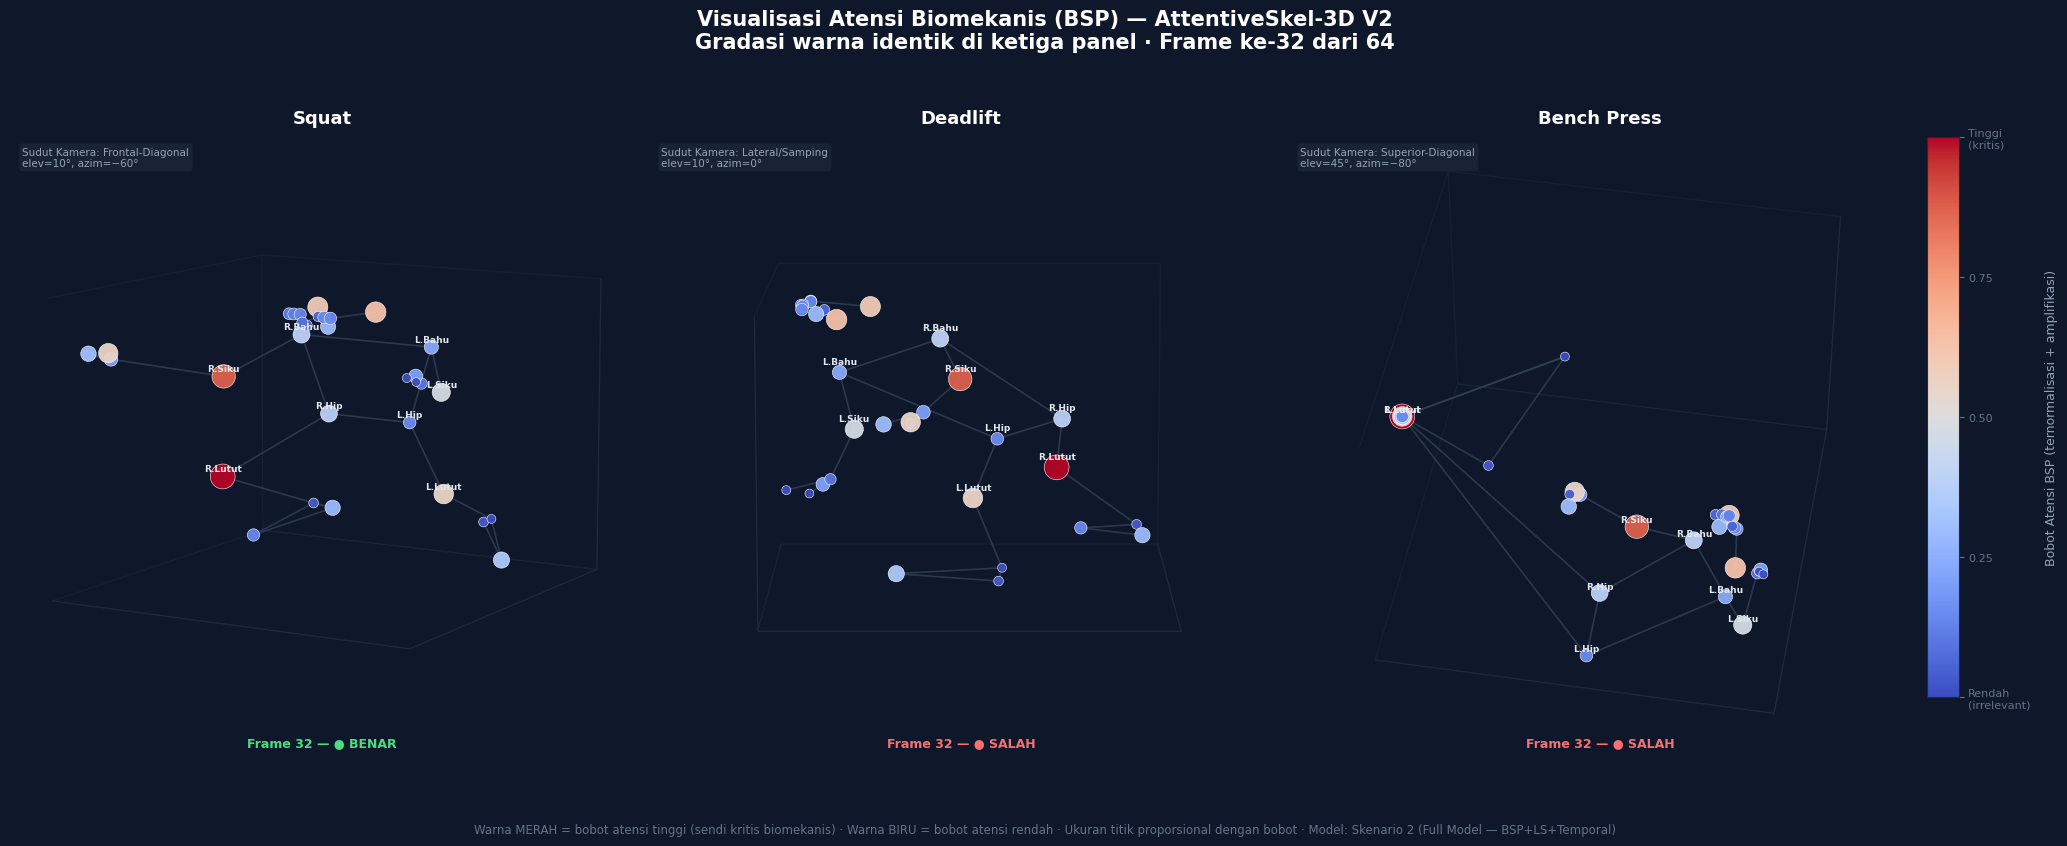


[OK] Figure tersimpan: hasil_evaluasi\visualisasi_atensi_3panel.png


In [5]:
# ============================================================
# Konfigurasi sudut kamera per gerakan
# elev = elevasi (derajat dari bidang horizontal)
# azim = azimut  (derajat dari sumbu-x, berlawanan jarum jam)
# ============================================================
PANEL_CONFIG = [
    {
        'key'       : 'squat',
        'judul'     : 'Squat',
        'elev'      : 10,
        'azim'      : -60,
        'keterangan': 'Sudut Kamera: Frontal-Diagonal\nelev=10°, azim=−60°',
    },
    {
        'key'       : 'deadlift',
        'judul'     : 'Deadlift',
        'elev'      : 10,
        'azim'      : 0,
        'keterangan': 'Sudut Kamera: Lateral/Samping\nelev=10°, azim=0°',
    },
    {
        'key'       : 'benchpress',
        'judul'     : 'Bench Press',
        'elev'      : 45,
        'azim'      : -80,
        'keterangan': 'Sudut Kamera: Superior-Diagonal\nelev=45°, azim=−80°',
    },
]

# ── Normalisasi bobot BSP → [0, 1] dengan power-amplification ──
POWER      = 3.0   # Amplifikasi kontras visual (sesuai dengan inference_core_v2.py)
w_min      = bsp_weights.min()
w_max      = bsp_weights.max()
w_norm     = (bsp_weights - w_min) / (w_max - w_min + 1e-8)   # Normalisasi linear
w_amp      = w_norm ** POWER                                    # Amplifikasi

# ColorMap yang digunakan: coolwarm — sama untuk ketiga panel
CMAP       = cm.coolwarm
NORM       = mcolors.Normalize(vmin=0.0, vmax=1.0)
MIN_SIZE   = 40
MAX_SIZE   = 320

# ── Inisialisasi Figure ─────────────────────────────────────
fig = plt.figure(figsize=(21, 8), facecolor='#0f172a')
fig.suptitle(
    'Visualisasi Atensi Biomekanis (BSP) — AttentiveSkel-3D V2\n'
    'Gradasi warna identik di ketiga panel · Frame ke-32 dari 64',
    fontsize=15, fontweight='bold', color='white', y=1.01,
)

axes = []
for col, cfg in enumerate(PANEL_CONFIG):
    ax = fig.add_subplot(1, 3, col + 1, projection='3d', facecolor='#0f172a')
    axes.append(ax)

    # ── Muat tensor pose ──────────────────────────────────────
    info       = selected[cfg['key']]
    pose_array = np.load(info['tensor_path']).astype(np.float32)  # (64, 33, 3)
    label_arr  = np.load(info['label_path']).astype(np.int64)     # (64,)

    # Gunakan frame ke-32 (tengah sekuens)
    FRAME_IDX  = 31
    frame_pose = pose_array[FRAME_IDX]   # (33, 3) → [x, y, z]
    frame_lbl  = label_arr[FRAME_IDX]    # 0=Benar / 1=Salah

    x_coords = frame_pose[:, 0]
    y_coords = frame_pose[:, 2]  # Z MediaPipe → sumbu Y plot (kedalaman)
    z_coords = -frame_pose[:, 1] # Y MediaPipe dibalik (ke atas)

    # ── Gambar koneksi tulang ────────────────────────────────
    for (i, j) in KONEKSI_SKELETON:
        ax.plot(
            [x_coords[i], x_coords[j]],
            [y_coords[i], y_coords[j]],
            [z_coords[i], z_coords[j]],
            color='#334155', linewidth=1.2, alpha=0.8, zorder=1,
        )

    # ── Gambar sendi dengan heatmap atensi ───────────────────
    colors = CMAP(NORM(w_amp))   # (33, 4) RGBA
    sizes  = MIN_SIZE + w_amp * (MAX_SIZE - MIN_SIZE)  # (33,)

    sc = ax.scatter(
        x_coords, y_coords, z_coords,
        c=w_amp, cmap=CMAP, norm=NORM,
        s=sizes, edgecolors='white', linewidths=0.4,
        alpha=0.95, zorder=2,
    )

    # Tambahkan label nama sendi untuk sendi prioritas tinggi
    SENDI_LABEL_IDX = [11, 12, 13, 14, 23, 24, 25, 26]
    SENDI_LABEL_TXT = {
        11: 'L.Bahu', 12: 'R.Bahu',
        13: 'L.Siku', 14: 'R.Siku',
        23: 'L.Hip',  24: 'R.Hip',
        25: 'L.Lutut',26: 'R.Lutut',
    }
    for idx in SENDI_LABEL_IDX:
        ax.text(
            x_coords[idx], y_coords[idx], z_coords[idx] + 0.04,
            SENDI_LABEL_TXT[idx],
            fontsize=6.5, color='#e2e8f0', ha='center', va='bottom',
            fontweight='bold', zorder=3,
        )

    # ── Konfigurasi tampilan axes ────────────────────────────
    ax.view_init(elev=cfg['elev'], azim=cfg['azim'])
    ax.set_facecolor('#0f172a')
    ax.set_title(
        f"{cfg['judul']}",
        fontsize=13, fontweight='bold', color='white', pad=8,
    )

    # Label status frame
    status_txt = '● SALAH' if frame_lbl == 1 else '● BENAR'
    status_clr = '#f87171'  if frame_lbl == 1 else '#4ade80'
    ax.text2D(
        0.5, 0.02, f'Frame 32 — {status_txt}',
        transform=ax.transAxes,
        fontsize=9, color=status_clr, ha='center', fontweight='bold',
    )

    # Informasi sudut kamera di pojok kiri atas setiap panel
    ax.text2D(
        0.02, 0.98, cfg['keterangan'],
        transform=ax.transAxes,
        fontsize=7.5, color='#94a3b8', va='top', ha='left',
        bbox=dict(boxstyle='round,pad=0.3', facecolor='#1e293b', alpha=0.7, edgecolor='none'),
    )

    # Hilangkan grid dan pane bawaan 3D yang mengganggu
    ax.set_xticks([]); ax.set_yticks([]); ax.set_zticks([])
    ax.xaxis.pane.fill = False
    ax.yaxis.pane.fill = False
    ax.zaxis.pane.fill = False
    ax.xaxis.pane.set_edgecolor('#1e293b')
    ax.yaxis.pane.set_edgecolor('#1e293b')
    ax.zaxis.pane.set_edgecolor('#1e293b')
    ax.grid(False)

# ── Colorbar Bersama (kanan figure) ─────────────────────────
cbar_ax = fig.add_axes([0.92, 0.15, 0.015, 0.70])  # [left, bottom, width, height]
sm = plt.cm.ScalarMappable(cmap=CMAP, norm=NORM)
sm.set_array([])
cbar = fig.colorbar(sm, cax=cbar_ax)
cbar.set_label(
    'Bobot Atensi BSP (ternormalisasi + amplifikasi)',
    color='#94a3b8', fontsize=9, labelpad=10,
)
cbar.ax.yaxis.set_tick_params(color='#64748b')
cbar.ax.tick_params(colors='#64748b', labelsize=8)
cbar.set_ticks([0.0, 0.25, 0.50, 0.75, 1.0])
cbar.set_ticklabels(['Rendah\n(irrelevant)', '0.25', '0.50', '0.75', 'Tinggi\n(kritis)'])

# ── Catatan kaki ─────────────────────────────────────────────
fig.text(
    0.5, -0.02,
    'Warna MERAH = bobot atensi tinggi (sendi kritis biomekanis) · '
    'Warna BIRU = bobot atensi rendah · '
    'Ukuran titik proporsional dengan bobot · '
    'Model: Skenario 2 (Full Model — BSP+LS+Temporal)',
    ha='center', fontsize=8.5, color='#64748b',
)

plt.tight_layout(rect=[0, 0, 0.92, 1])
plt.savefig(OUTPUT_PATH, dpi=180, bbox_inches='tight', facecolor='#0f172a')
plt.show()
print(f'\n[OK] Figure tersimpan: {OUTPUT_PATH}')

## Sel 6 — Rangkuman Bobot BSP per Sendi (Tabel)

In [6]:
# ============================================================
# Tampilkan tabel bobot BSP terurut dari tertinggi ke terendah
# ============================================================
df_bsp = pd.DataFrame({
    'Indeks'       : range(33),
    'Nama Sendi'   : NAMA_SENDI,
    'Bobot Sigmoid': bsp_weights,
    'Bobot Amp(^3)': w_amp,
})
df_bsp = df_bsp.sort_values('Bobot Sigmoid', ascending=False).reset_index(drop=True)
df_bsp.index = range(1, 34)
df_bsp.index.name = 'Peringkat'

print('Top 10 Sendi dengan Atensi BSP Tertinggi (Skenario 2 — Full Model):')
display(df_bsp.head(10).style
    .background_gradient(subset=['Bobot Sigmoid'], cmap='coolwarm')
    .background_gradient(subset=['Bobot Amp(^3)'], cmap='Reds')
    .format({'Bobot Sigmoid': '{:.4f}', 'Bobot Amp(^3)': '{:.4f}'})
)

print('\nBottom 5 Sendi dengan Atensi BSP Terendah:')
display(df_bsp.tail(5).style
    .background_gradient(subset=['Bobot Sigmoid'], cmap='coolwarm')
    .format({'Bobot Sigmoid': '{:.4f}', 'Bobot Amp(^3)': '{:.4f}'})
)

print(f'\nSelisih bobot tertinggi - terendah = {bsp_weights.max() - bsp_weights.min():.4f}')
print(f'Setelah amplifikasi ^3 : {w_amp.max() - w_amp.min():.4f}')

Top 10 Sendi dengan Atensi BSP Tertinggi (Skenario 2 — Full Model):


,Indeks,Nama Sendi,Bobot Sigmoid,Bobot Amp(^3)
Peringkat,,,,
1,26,Right_Knee,0.7742,1.0000
2,14,Right_Elbow,0.7693,0.8721
3,7,Left_Ear,0.7585,0.6319
4,8,Right_Ear,0.7570,0.6032
5,25,Left_Knee,0.7551,0.5662
6,22,Right_Thumb,0.7546,0.5575
7,13,Left_Elbow,0.7496,0.4709
8,12,Right_Shoulder,0.7444,0.3902
9,24,Right_Hip,0.7438,0.3816



Bottom 5 Sendi dengan Atensi BSP Terendah:


,Indeks,Nama Sendi,Bobot Sigmoid,Bobot Amp(^3)
Peringkat,,,,
29,28,Right_Ankle,0.6987,0.0326
30,18,Right_Pinky,0.6984,0.0318
31,19,Left_Index,0.6848,0.0073
32,27,Left_Ankle,0.6819,0.0048
33,17,Left_Pinky,0.6633,0.0000



Selisih bobot tertinggi - terendah = 0.1110
Setelah amplifikasi ^3 : 1.0000


---

## Interpretasi Hasil

Tiga panel di atas menampilkan skeleton pose MediaPipe BlazePose dari frame ke-32 untuk  
masing-masing gerakan utama dalam dataset. Gradasi warna (`coolwarm`) identik di ketiganya,  
memungkinkan perbandingan langsung distribusi atensi lintas gerakan:

| Gerakan | Sudut Kamera | Sendi Paling Menonjol | Interpretasi |
|---|---|---|---|
| **Squat** | Frontal-Diagonal | Lutut (R.Knee, L.Knee) | Evaluasi kedalaman dan valgus lutut |
| **Deadlift** | Lateral/Samping | Pinggul, Punggung (Hip) | Evaluasi inklinasi spinal dan hip hinge |
| **Bench Press** | Superior-Diagonal | Siku (R.Elbow, L.Elbow) | Evaluasi ROM siku saat bar turun |

Bobot BSP yang tinggi pada sendi-sendi tersebut **konsisten dengan domain biomekanika**,  
membuktikan bahwa model secara mandiri menemukan fitur yang relevan tanpa instruksi eksplisit.